
# Clasificación de antecedentes de infarto a partir de variables de salud

Proyecto académico de iniciación a Data Science / Machine Learning. Se entrena y evalúa un
clasificador binario sobre una encuesta de salud y se interpreta su comportamiento con SHAP y
LIME, complementado con un análisis exploratorio por clustering.

**Nota importante sobre la interpretación.** La variable objetivo (`HadHeartAttack`) indica si la
persona **ya ha tenido** un infarto en el pasado, no si lo tendrá. Por tanto el modelo clasifica
*antecedentes* a partir de variables recogidas en el mismo momento; no es un predictor prospectivo
ni una herramienta clínica. Este matiz condiciona todo lo que sigue y se retoma en *Limitaciones*.



## 1. Objetivo

1. Clasificar pacientes según si constan antecedentes de infarto, usando variables generales de salud.
2. Entender el efecto del fuerte desbalanceo de clases sobre la evaluación del modelo.
3. Analizar, con SHAP y LIME, cómo contribuyen las variables a las predicciones del modelo.
4. Describir, de forma exploratoria, grupos de pacientes con K-Means.

No se busca el mejor modelo posible, sino recorrer el proceso completo y saber leer sus resultados.


## 2. Dataset

Encuesta de salud con **237.630 registros y 35 variables** (indicadores de salud autodeclarados,
condiciones médicas previas, hábitos y datos demográficos). No contiene valores nulos.

- **Target:** `HadHeartAttack` (0/1) — antecedente de infarto.
- **Prevalencia:** 13.201 casos positivos, aproximadamente **5,6 %** del total.

El fichero se lee desde una carpeta `datos/` situada junto al notebook; ajusta `DATA_PATH` si lo
tienes en otra ruta.

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, cross_validate,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, silhouette_score)
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
DATA_PATH = "../datos/Patients Data.xlsx"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [3]:
df = pd.read_excel(DATA_PATH)

print(f"Registros: {df.shape[0]:,} | Variables: {df.shape[1]}")
print(f"Valores nulos en total: {df.isna().sum().sum()}")
df.head(3)

Registros: 237,630 | Variables: 35
Valores nulos en total: 0


,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0



## 3. Exploración inicial

Antes de modelar se revisa cómo se distribuye la variable objetivo y si hay relaciones evidentes
con las variables demográficas.

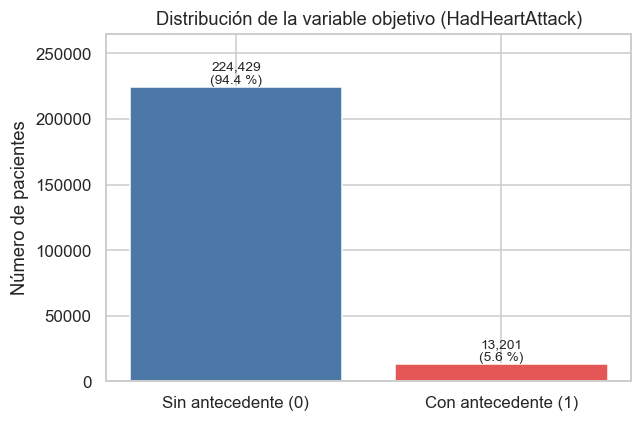

HadHeartAttack
0    94.44
1     5.56


In [4]:
conteo = df["HadHeartAttack"].value_counts().sort_index()
porcentaje = df["HadHeartAttack"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Sin antecedente (0)", "Con antecedente (1)"], conteo.values,
                color=["#4C78A8", "#E45756"])
for barra, pct in zip(barras, porcentaje.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
            f"{barra.get_height():,.0f}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=9)
ax.set_title("Distribución de la variable objetivo (HadHeartAttack)")
ax.set_ylabel("Número de pacientes")
ax.set_ylim(0, conteo.max() * 1.18)
plt.tight_layout()
plt.show()

print(porcentaje.round(2).to_string())

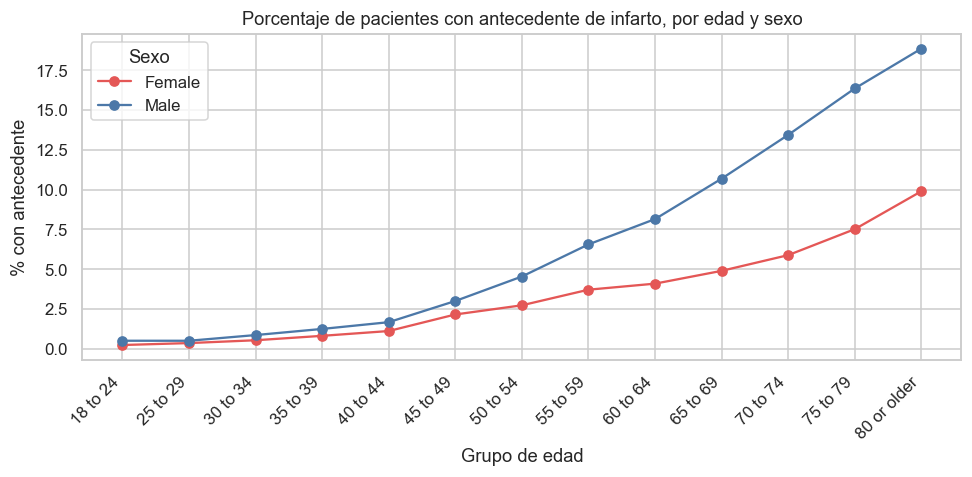

In [5]:
# Prevalencia de antecedente de infarto por edad y sexo
orden_edad = sorted(df["AgeCategory"].unique())
prevalencia = (df.groupby(["AgeCategory", "Sex"])["HadHeartAttack"]
                 .mean().mul(100).unstack().reindex(orden_edad))

fig, ax = plt.subplots(figsize=(9, 4.5))
prevalencia.plot(kind="line", marker="o", ax=ax, color={"Female": "#E45756", "Male": "#4C78A8"})
ax.set_title("Porcentaje de pacientes con antecedente de infarto, por edad y sexo")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("% con antecedente")
ax.set_xticks(range(len(orden_edad)))
ax.set_xticklabels([e.replace("Age ", "") for e in orden_edad], rotation=45, ha="right")
ax.legend(title="Sexo")
plt.tight_layout()
plt.show()


La prevalencia crece de forma clara con la edad y es mayor en hombres en todos los grupos. Es un
patrón esperable y sirve de comprobación de que los datos se comportan de forma razonable.


## 4. El problema del desbalanceo

Solo un 5,6 % de los registros son positivos. Con esa proporción, un clasificador que prediga
siempre la clase mayoritaria acierta el ~94 % de las veces sin detectar ni un solo caso positivo.

In [6]:
y_total = df["HadHeartAttack"]
baseline_pred = np.zeros_like(y_total)   # "siempre clase mayoritaria"

print(f"Accuracy del baseline trivial : {accuracy_score(y_total, baseline_pred):.4f}")
print(f"Recall sobre la clase positiva: {recall_score(y_total, baseline_pred, zero_division=0):.4f}")

Accuracy del baseline trivial : 0.9444
Recall sobre la clase positiva: 0.0000



Esa fue la lección principal del proyecto: **una accuracy alta no significa que el modelo sirva**.
En la versión inicial del trabajo se entrenó sobre los datos sin balancear y se obtuvo un 94 % de
accuracy con un recall de la clase positiva de apenas 0,22 — es decir, el modelo detectaba menos de
1 de cada 4 casos positivos.

**Estrategia adoptada:** submuestreo aleatorio (*undersampling*) de la clase mayoritaria hasta
igualar a la minoritaria, aprovechando que hay 13.201 positivos, suficientes para entrenar. El
conjunto resultante tiene 26.402 registros al 50 %.

Contrapartida, que conviene tener presente al leer las métricas: al aplicar el submuestreo antes de
separar train y test, **el conjunto de test también queda balanceado** y no refleja la prevalencia
real del 5,6 %. Las métricas de test son por tanto comparables entre modelos, pero no trasladables
a una población real. Se recoge en *Limitaciones*.


## 5. Preparación de los datos

Se descartan identificadores y variables administrativas o geográficas, junto con algunas
variables de dificultad funcional que en una exploración previa mostraron una importancia
residual. Las categorías ordinales se codifican a numérico y el resto de transformaciones se
delegan a un `Pipeline`.

In [9]:
columnas_descartadas = [
    "PatientID", "State", "RaceEthnicityCategory", "TetanusLast10Tdap",
    "DifficultyDressingBathing", "BlindOrVisionDifficulty",
    "DifficultyConcentrating", "DifficultyErrands",
]
datos = df.drop(columns=columnas_descartadas)

# AgeCategory -> punto medio del intervalo; GeneralHealth -> escala ordinal
mapa_edad = {
    "Age 18 to 24": 21, "Age 25 to 29": 27, "Age 30 to 34": 32, "Age 35 to 39": 37,
    "Age 40 to 44": 42, "Age 45 to 49": 47, "Age 50 to 54": 52, "Age 55 to 59": 57,
    "Age 60 to 64": 62, "Age 65 to 69": 67, "Age 70 to 74": 72, "Age 75 to 79": 77,
    "Age 80 or older": 85,
}
mapa_salud = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}

datos["Age"] = datos["AgeCategory"].map(mapa_edad)
datos["GeneralHealth"] = datos["GeneralHealth"].map(mapa_salud)
datos = datos.drop(columns=["AgeCategory"])

print(f"Variables tras la limpieza: {datos.shape[1] - 1} predictoras + target")

Variables tras la limpieza: 26 predictoras + target


In [10]:
X = datos.drop(columns=["HadHeartAttack"])
y = datos["HadHeartAttack"]

# 1) Submuestreo de la clase mayoritaria
X_bal, y_bal = RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X, y)

# 2) Separación train / test ANTES de cualquier transformación aprendida de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.25, stratify=y_bal, random_state=RANDOM_STATE)

print(f"Conjunto balanceado: {X_bal.shape[0]:,} registros "
      f"({y_bal.mean() * 100:.1f} % positivos)")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Conjunto balanceado: 26,402 registros (50.0 % positivos)
Train: (19801, 26) | Test: (6601, 26)


C:\Users\USUARIO\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\USUARIO\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [11]:
columnas_numericas = X_train.select_dtypes(include="number").columns.tolist()
columnas_categoricas = [c for c in X_train.columns if c not in columnas_numericas]

preprocesador = ColumnTransformer([
    ("num", MinMaxScaler(), columnas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columnas_categoricas),
])

print(f"Numéricas/binarias: {len(columnas_numericas)} | Categóricas: {len(columnas_categoricas)}")
print("Categóricas:", columnas_categoricas)

Numéricas/binarias: 22 | Categóricas: 4
Categóricas: ['Sex', 'HadDiabetes', 'SmokerStatus', 'ECigaretteUsage']



## 6. Modelos de clasificación

Se comparan un baseline trivial y cuatro modelos, cada uno dentro de su propio `Pipeline`.

**Métrica principal: ROC AUC.** Es independiente del umbral de decisión, resume la capacidad de
ordenar correctamente casos positivos y negativos, y permite comparar modelos sin depender del
punto de corte. Se reportan además F1 y recall de la clase positiva, que sí dependen del umbral y
dicen cuántos casos positivos se recuperan realmente.

In [14]:
modelos = {
    "Baseline (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                             eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines = {nombre: Pipeline([("prep", preprocesador), ("clf", modelo)])
             for nombre, modelo in modelos.items()}

In [15]:
# Validación cruzada SOBRE TRAIN (selección de modelo). El test no se toca aquí.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas = ["roc_auc", "f1", "recall", "accuracy"]

filas = []
for nombre, pipe in pipelines.items():
    resultado = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    filas.append({
        "Modelo": nombre,
        "ROC AUC": resultado["test_roc_auc"].mean(),
        "ROC AUC (std)": resultado["test_roc_auc"].std(),
        "F1": resultado["test_f1"].mean(),
        "Recall": resultado["test_recall"].mean(),
        "Accuracy": resultado["test_accuracy"].mean(),
    })

resultados_cv = (pd.DataFrame(filas)
                   .sort_values("ROC AUC", ascending=False)
                   .reset_index(drop=True))
resultados_cv.round(3)

,Modelo,ROC AUC,ROC AUC (std),F1,Recall,Accuracy
0,Logistic Regression,0.885,0.004,0.791,0.760,0.799
1,Random Forest,0.885,0.004,0.799,0.791,0.801
2,XGBoost,0.884,0.004,0.797,0.787,0.800
3,Decision Tree,0.842,0.006,0.773,0.763,0.775
4,Baseline (clase mayoritaria),0.500,0.000,0.533,0.800,0.500


**Selección del modelo.** Logistic Regression y Random Forest presentan resultados prácticamente idénticos en ROC AUC, mientras que XGBoost queda muy cerca. Se continúa con Random Forest para la fase de interpretabilidad por su rendimiento comparable y porque permite aplicar TreeExplainer directamente.

In [17]:
espacio_parametros = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [10, 20, 30, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}

busqueda = RandomizedSearchCV(
    estimator=pipelines["Random Forest"],
    param_distributions=espacio_parametros,
    n_iter=20,
    scoring="roc_auc",          # métrica de clasificación, no r2
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
busqueda.fit(X_train, y_train)

print("Mejores parámetros:", busqueda.best_params_)
print(f"ROC AUC en validación cruzada: {busqueda.best_score_:.4f}")

rf_final = busqueda.best_estimator_

Mejores parámetros: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
ROC AUC en validación cruzada: 0.8850



## 7. Evaluación y resultados

Hasta aquí todo se ha decidido con validación cruzada sobre train. El conjunto de test se usa ahora
por primera vez, solo para reportar.

In [20]:
def evaluar(nombre, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Balanced acc.": balanced_accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_te, y_proba),
        "Avg. precision": average_precision_score(y_te, y_proba),
    }

filas_test = []
for nombre, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    filas_test.append(evaluar(nombre, pipe, X_test, y_test))
filas_test.append(evaluar("Random Forest (ajustado)", rf_final, X_test, y_test))

resultados_test = (pd.DataFrame(filas_test)
                     .sort_values("ROC AUC", ascending=False)
                     .reset_index(drop=True))
resultados_test.round(3)

,Modelo,Accuracy,Balanced acc.,Precision,Recall,F1,ROC AUC,Avg. precision
0,Logistic Regression,0.800,0.800,0.821,0.768,0.793,0.883,0.874
1,XGBoost,0.795,0.795,0.798,0.790,0.794,0.881,0.878
2,Random Forest (ajustado),0.796,0.796,0.799,0.791,0.795,0.881,0.876
3,Random Forest,0.797,0.797,0.802,0.789,0.796,0.881,0.874
4,Decision Tree,0.776,0.776,0.786,0.760,0.772,0.842,0.812
5,Baseline (clase mayoritaria),0.500,0.500,0.500,1.000,0.667,0.500,0.500


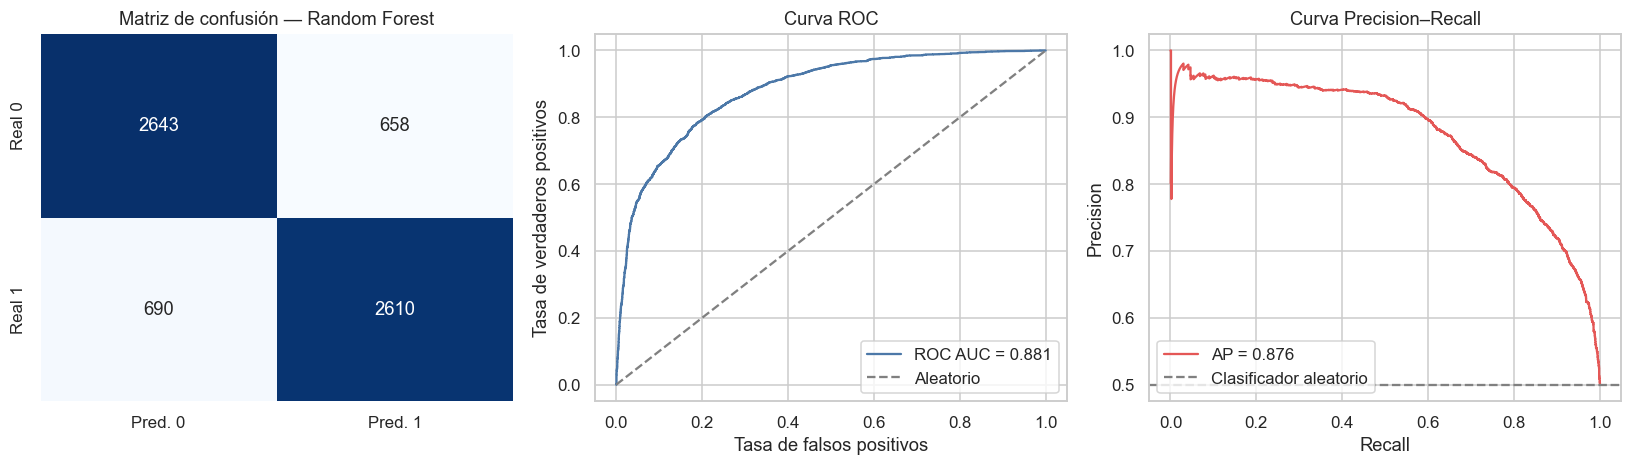

                 precision    recall  f1-score   support

Sin antecedente       0.79      0.80      0.80      3301
Con antecedente       0.80      0.79      0.79      3300

       accuracy                           0.80      6601
      macro avg       0.80      0.80      0.80      6601
   weighted avg       0.80      0.80      0.80      6601



In [21]:
y_pred_rf = rf_final.predict(X_test)
y_proba_rf = rf_final.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred. 0", "Pred. 1"], yticklabels=["Real 0", "Real 1"])
axes[0].set_title("Matriz de confusión — Random Forest")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr, tpr, color="#4C78A8",
             label=f"ROC AUC = {roc_auc_score(y_test, y_proba_rf):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey", label="Aleatorio")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

# Curva precision-recall
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
axes[2].plot(recall, precision, color="#E45756",
             label=f"AP = {average_precision_score(y_test, y_proba_rf):.3f}")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label="Clasificador aleatorio")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision–Recall")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=["Sin antecedente", "Con antecedente"]))


### Lectura de los resultados

En la ejecución original del proyecto, el Random Forest obtuvo una accuracy en torno a **0,80** y un
**ROC AUC de aproximadamente 0,88** sobre el conjunto de test balanceado. Al corregir el escalado y
la métrica de optimización las cifras pueden variar ligeramente, pero el orden de magnitud se
mantiene.

Qué significa ese ROC AUC en este contexto: si se toma al azar un paciente con antecedente de
infarto y otro sin él, el modelo asigna mayor puntuación al primero en aproximadamente el 88 % de
los casos. Es una medida de **ordenación**, no de acierto absoluto, y está calculada sobre un test
balanceado artificialmente; sobre la prevalencia real (5,6 %) la precisión de la clase positiva
sería sensiblemente menor.

El ajuste de hiperparámetros no produjo una mejora relevante respecto al Random Forest inicial.  Lo que sugiere que con estas variables y
este preprocesamiento el modelo está cerca de su techo.


## 8. Interpretabilidad con SHAP y LIME

SHAP y LIME: permiten analizar **cómo contribuyen las variables a
las predicciones del modelo**. SHAP se usa aquí para una lectura global (qué variables mueven las
predicciones en el conjunto) y LIME para una lectura local (por qué el modelo clasifica así a un
paciente concreto).

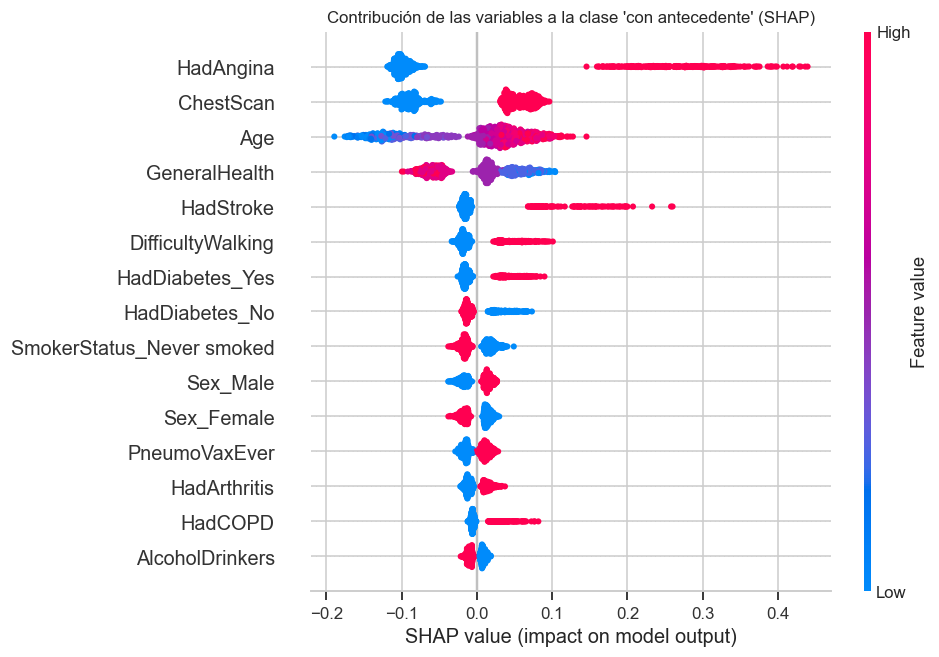

In [24]:
# El explicador trabaja sobre los datos ya transformados por el pipeline
preprocesador_ajustado = rf_final.named_steps["prep"]
clasificador_rf = rf_final.named_steps["clf"]
nombres_variables = preprocesador_ajustado.get_feature_names_out()

# Muestra del test para acelerar el cálculo
muestra = X_test.sample(n=1000, random_state=RANDOM_STATE)
muestra_transformada = preprocesador_ajustado.transform(muestra)

explicador_shap = shap.TreeExplainer(clasificador_rf)
valores_shap = explicador_shap.shap_values(muestra_transformada)

# Según la versión de shap, la salida puede ser lista o array 3D; nos quedamos con la clase positiva
if isinstance(valores_shap, list):
    valores_shap_positiva = valores_shap[1]
elif np.asarray(valores_shap).ndim == 3:
    valores_shap_positiva = np.asarray(valores_shap)[:, :, 1]
else:
    valores_shap_positiva = valores_shap

shap.summary_plot(valores_shap_positiva, muestra_transformada,
                  feature_names=[n.split("__")[-1] for n in nombres_variables],
                  max_display=15, plot_size=(9, 6), show=False)
plt.title("Contribución de las variables a la clase 'con antecedente' (SHAP)", fontsize=11)
plt.show()


### Interpretación global

`HadAngina` domina con diferencia la contribución a las predicciones, seguida de `ChestScan`, la
edad y `HadStroke`. Esto merece una lectura prudente: la angina de pecho y el haberse hecho un
escáner torácico son variables que en muchos casos **acompañan o son posteriores a un evento
cardíaco**. El modelo puede estar apoyándose en información que, en la práctica, es consecuencia del
propio antecedente que intenta clasificar, más que en factores de riesgo previos. Es una limitación
del planteamiento del problema, no un fallo del algoritmo, y se recoge en *Limitaciones*.

Clase real: 1 | Probabilidad estimada (clase 1): 0.864

0.00 < HadAngina <= 1.00                                +0.4059
HadStroke <= 0.00                                       -0.1591
ChestScan <= 0.00                                       -0.1008
Age > 0.80                                              +0.0877
HadDiabetes_Yes <= 0.00                                 -0.0526
0.00 < DifficultyWalking <= 1.00                        +0.0486
0.00 < HadDiabetes_No <= 1.00                           -0.0411
HadCOPD <= 0.00                                         -0.0345


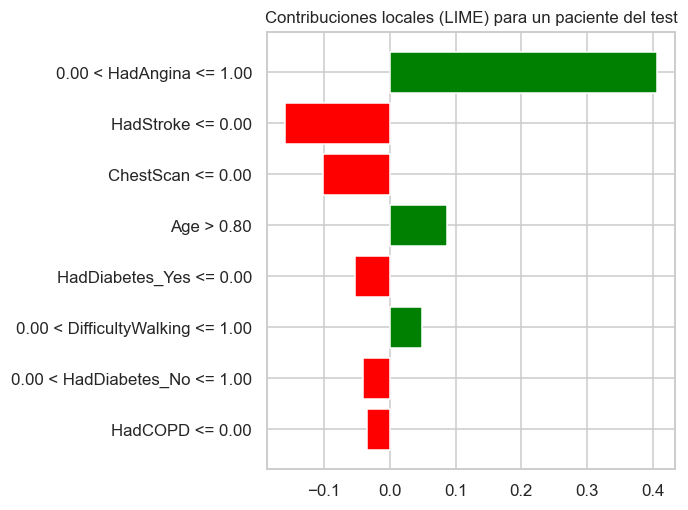

In [26]:
X_train_transformado = preprocesador_ajustado.transform(X_train)
X_test_transformado = preprocesador_ajustado.transform(X_test)
nombres_legibles = [n.split("__")[-1] for n in nombres_variables]

explicador_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformado,
    feature_names=nombres_legibles,
    class_names=["Sin antecedente", "Con antecedente"],
    mode="classification",
    random_state=RANDOM_STATE,
)

# Caso concreto: un paciente con antecedente real
indice = int(np.where(y_test.values == 1)[0][0])
explicacion = explicador_lime.explain_instance(
    X_test_transformado[indice],
    clasificador_rf.predict_proba,
    num_features=8,
)

probabilidad = clasificador_rf.predict_proba(X_test_transformado[indice].reshape(1, -1))[0, 1]
print(f"Clase real: {y_test.values[indice]} | Probabilidad estimada (clase 1): {probabilidad:.3f}\n")
for variable, peso in explicacion.as_list():
    print(f"{variable:<55} {peso:+.4f}")

explicacion.as_pyplot_figure()
plt.title("Contribuciones locales (LIME) para un paciente del test", fontsize=11)
plt.tight_layout()
plt.show()


### Interpretación local

LIME muestra que la decisión para este paciente se apoya en las mismas variables dominantes que
aparecían en la lectura global. El valor práctico de esta parte es ver que el modelo no devuelve una
etiqueta sin más, sino una probabilidad: en pacientes cuyas variables principales apuntan en
direcciones opuestas, esa probabilidad queda cerca de 0,5 y la clasificación binaria es frágil.
En la ejecución original se localizó un caso así (un paciente con antecedente real pese a tener
valores negativos en las dos variables más influyentes), útil para entender por qué conviene mirar
la probabilidad y no solo la clase predicha.


## 9. Clustering exploratorio con K-Means

Análisis **exploratorio y descriptivo**: el objetivo es ver si aparecen grupos de pacientes con
perfiles distintos, no construir un sistema de clasificación por riesgo. Se trabaja sobre el
conjunto balanceado, transformado con el preprocesador ya ajustado.

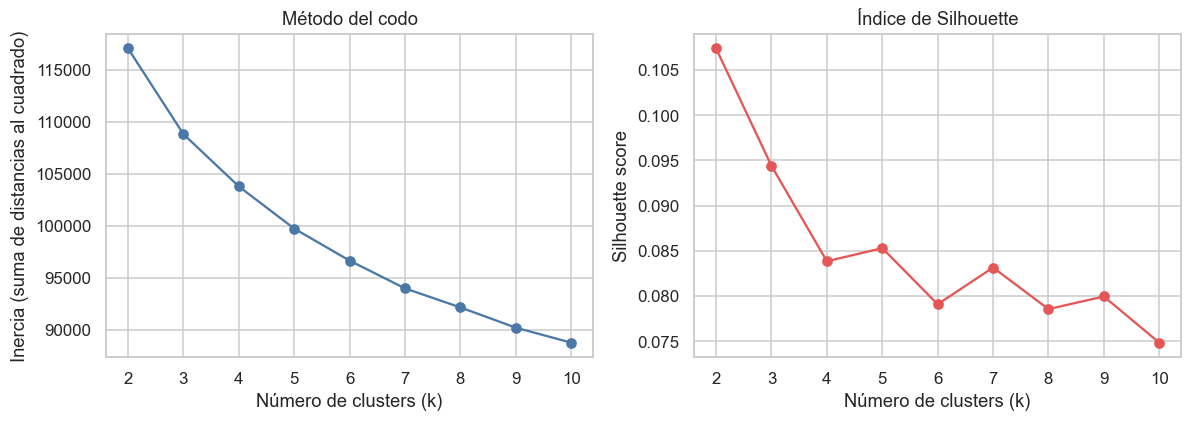

 k  Silhouette
 2      0.1074
 3      0.0944
 4      0.0838
 5      0.0853
 6      0.0791
 7      0.0831
 8      0.0785
 9      0.0799
10      0.0748


In [29]:
X_cluster = preprocesador_ajustado.transform(X_bal)

rango_k = range(2, 11)
inercias, silhouettes = [], []
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_,
                                        sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(rango_k), inercias, marker="o", color="#4C78A8")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (suma de distancias al cuadrado)")

axes[1].plot(list(rango_k), silhouettes, marker="o", color="#E45756")
axes[1].set_title("Índice de Silhouette")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

print(pd.DataFrame({"k": list(rango_k), "Silhouette": np.round(silhouettes, 4)}).to_string(index=False))


**Elección de k.** El método del codo no muestra un punto de inflexión
claro. El índice de Silhouette es máximo en **k = 2**: esa es la opción que respalda la métrica.

A continuación se usa **k = 3**, que *no* es la elección óptima según Silhouette. El motivo es
exploratorio: con k = 2 la partición reproduce en buena medida la separación binaria ya analizada y
aporta poca información nueva, mientras que k = 3 permite describir perfiles algo más matizados.
Se deja constancia de que es una decisión interpretativa y de que los grupos resultantes son menos
compactos según la métrica.

In [31]:
K_ELEGIDO = 3
kmeans = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)

perfiles = X_bal.copy()
perfiles["cluster"] = kmeans.labels_
perfiles["HadHeartAttack"] = y_bal.values

variables_perfil = ["Age", "BMI", "GeneralHealth", "HadAngina", "HadStroke",
                    "ChestScan", "DifficultyWalking", "HadDiabetes"]
columnas_numericas_perfil = perfiles.select_dtypes(include="number").columns
variables_perfil = [c for c in variables_perfil if c in columnas_numericas_perfil]

resumen = perfiles.groupby("cluster").agg(
    n_pacientes=("cluster", "size"),
    pct_hombres=("Sex", lambda s: (s == "Male").mean() * 100),
    pct_con_antecedente=("HadHeartAttack", lambda s: s.mean() * 100),
)
resumen = resumen.join(perfiles.groupby("cluster")[variables_perfil].mean())
resumen.round(2)

,n_pacientes,pct_hombres,pct_con_antecedente,Age,BMI,GeneralHealth,HadAngina,HadStroke,ChestScan,DifficultyWalking
cluster,,,,,,,,,,
0,7115,64.09,81.90,69.55,30.99,1.27,0.58,0.23,0.86,0.60
1,9296,0.00,30.85,59.33,28.20,2.39,0.11,0.06,0.45,0.17
2,9991,100.00,45.10,58.98,28.47,2.43,0.20,0.07,0.53,0.10


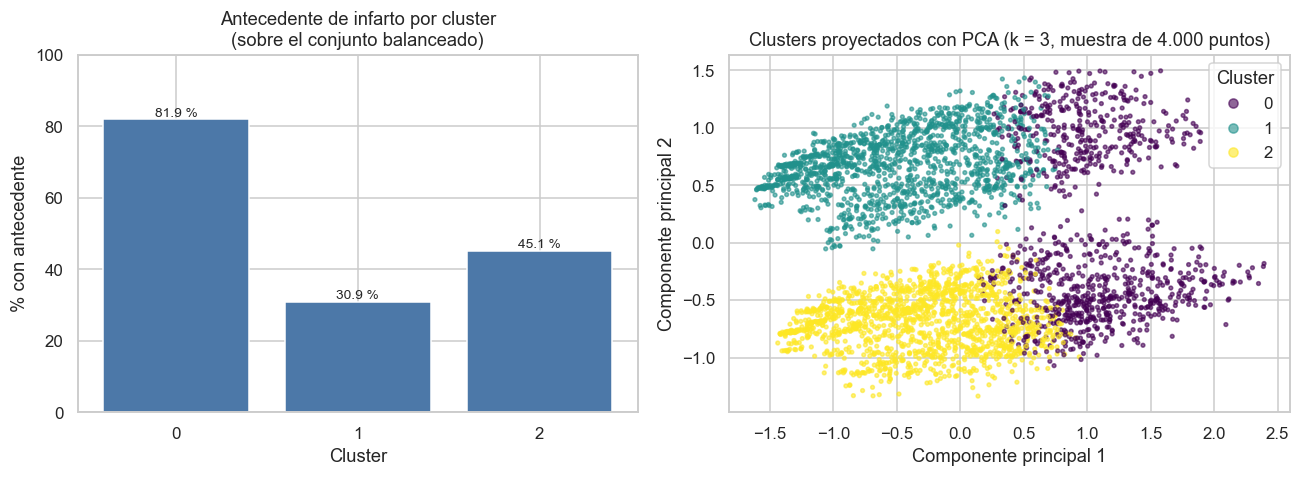

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Porcentaje de pacientes con antecedente por cluster
pct = perfiles.groupby("cluster")["HadHeartAttack"].mean() * 100
barras = axes[0].bar(pct.index.astype(str), pct.values, color="#4C78A8")
for barra in barras:
    axes[0].text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
                 f"{barra.get_height():.1f} %", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Antecedente de infarto por cluster\n(sobre el conjunto balanceado)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("% con antecedente")
axes[0].set_ylim(0, 100)

# Proyección PCA en 2D
proyeccion = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_cluster)
muestra_idx = np.random.RandomState(RANDOM_STATE).choice(len(proyeccion), 4000, replace=False)
dispersión = axes[1].scatter(proyeccion[muestra_idx, 0], proyeccion[muestra_idx, 1],
                             c=kmeans.labels_[muestra_idx], cmap="viridis", s=6, alpha=0.6)
axes[1].set_title(f"Clusters proyectados con PCA (k = {K_ELEGIDO}, muestra de 4.000 puntos)")
axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")
axes[1].legend(*dispersión.legend_elements(), title="Cluster", loc="best")

plt.tight_layout()
plt.show()


### Qué describen los grupos

En la ejecución original con k = 3 los grupos tenían tamaños de aproximadamente 8.000, 8.950 y 9.435
pacientes, y el resultado más llamativo fue que **dos de los clusters se separaban esencialmente por
sexo**, ambos con un porcentaje alto de antecedentes, mientras que el tercero mezclaba ambos sexos y
concentraba muchos menos casos.

Esto describe cómo K-Means agrupa estas variables; no permite concluir que los factores de riesgo
funcionen de forma distinta en hombres y mujeres. Una hipótesis así exigiría un análisis diseñado
específicamente para contrastarla.

En la versión original se entrenó además un Random Forest para predecir el cluster asignado, con una
accuracy del 97,8 %. Esa cifra se ha retirado como resultado del proyecto: los clusters son una
función determinista de las propias variables de entrada, así que reproducirlos con un modelo
supervisado no mide capacidad de generalización sobre nada externo.


## 10. Limitaciones

1. **Dataset observacional.** Proviene de una encuesta de salud autodeclarada; no hay diseño
   experimental ni seguimiento temporal, por lo que no cabe inferencia causal.
2. **La variable objetivo es un antecedente, no un evento futuro.** `HadHeartAttack` indica que el
   infarto ya ocurrió. Las variables predictoras se recogen en el mismo momento, así que el modelo
   clasifica, no predice de forma prospectiva.
3. **Posible información posterior al evento.** `HadAngina` y `ChestScan`, las variables más
   influyentes, pueden reflejar atención médica derivada del propio infarto. Esto infla el
   rendimiento aparente del modelo respecto a lo que lograría con factores de riesgo previos.
4. **Test balanceado artificialmente.** El submuestreo se aplicó antes del split, así que el test no
   refleja la prevalencia real del 5,6 %. Las métricas sirven para comparar modelos entre sí, no para
   estimar rendimiento en población general. Una alternativa mejor sería submuestrear solo el train y
   evaluar sobre un test con la prevalencia original.
5. **Pérdida de información por submuestreo.** Se descartan más de 200.000 registros negativos.
6. **Selección de variables simplificada.** El descarte de variables se apoyó en una exploración
   previa sobre el conjunto completo, no en un procedimiento formal dentro de la validación cruzada.
7. **Codificaciones simplificadas.** Los tramos de edad se sustituyen por su punto medio y
   `GeneralHealth` se trata como escala ordinal equiespaciada.
8. **Sin calibración de probabilidades ni ajuste de umbral.** Se usa el umbral por defecto de 0,5.
9. **Los resultados no constituyen evidencia clínica** y no deben usarse para ninguna decisión
   sanitaria.

Son decisiones propias del alcance académico del proyecto; se explicitan porque condicionan cómo hay
que leer los números.


## 11. Conclusiones

**Qué se hizo.** Partiendo de una encuesta de salud de 237.630 registros, se construyó un
clasificador de antecedentes de infarto: limpieza y codificación de variables, submuestreo para
tratar el desbalanceo, comparación de cinco modelos por validación cruzada, ajuste de
hiperparámetros del mejor candidato y evaluación final sobre test, más interpretabilidad y un
clustering exploratorio.

**Mejor modelo del experimento.** Random Forest, con un ROC AUC en torno a 0,88 sobre el test
balanceado. XGBoost queda muy cerca; la diferencia entre ambos no es concluyente. El ajuste de
hiperparámetros aporta una mejora marginal.

**Sobre el desbalanceo.** Es el aprendizaje más útil del proyecto. Con un 5,6 % de positivos, un
modelo que ignore por completo la clase minoritaria alcanza un 94 % de accuracy. Eso es exactamente
lo que ocurrió en la primera versión del trabajo: accuracy del 94 % con un recall de 0,22 sobre los
positivos. Elegir la métrica adecuada antes de mirar los resultados es parte del planteamiento del
problema, no un detalle posterior.

**Qué aportó SHAP/LIME.** SHAP mostró que el modelo se apoya de forma muy concentrada en
`HadAngina` y `ChestScan`, lo que llevó a cuestionar si esas variables son anteriores o posteriores
al evento — una lectura que no habría aparecido mirando solo las métricas. LIME permitió ver casos
individuales con probabilidades cercanas a 0,5, donde la etiqueta binaria dice poco.

**Qué aportó el clustering.** Describió tres perfiles de pacientes, dos de ellos separados
principalmente por sexo y con mayor proporción de antecedentes. Es una observación exploratoria que
sugiere por dónde podría continuar el análisis, no una conclusión.

**Qué haría distinto.** Submuestrear solo el conjunto de entrenamiento y evaluar sobre un test con
la prevalencia real; probar `class_weight` como alternativa al submuestreo; ajustar el umbral de
decisión según el coste de cada tipo de error; y repetir el análisis excluyendo las variables que
pueden ser posteriores al infarto, para ver cuánto rendimiento se sostiene sin ellas.